## Hierarchial methods

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sns

import sklearn
import sklearn.metrics as sm

In [2]:
from sklearn.cluster import AgglomerativeClustering

import scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

In [3]:
np.set_printoptions(precision=4, suppress=True)
plt.figure(figsize=(10, 3))
%matplotlib inline
sns.set_style("whitegrid")

<Figure size 1000x300 with 0 Axes>

In [ ]:
address = 'G:\\Meu Drive\\Cursos\\Python\\MachineLearning\\Parte2\\data\\mtcars.csv'

cars = pd.read_csv(address)
cars.columns = ['car_names','mpg','cyl','disp','hp','drat','wt','qsec','vs','am','gear','carb']
cars

,car_names,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [13]:
X = cars[['mpg','disp','hp','wt']].values
y = cars.iloc[:,(9)].values
print("X",X[0:10])
print("y",y[0:10])

X [[ 21.    160.    110.      2.62 ]
 [ 21.    160.    110.      2.875]
 [ 22.8   108.     93.      2.32 ]
 [ 21.4   258.    110.      3.215]
 [ 18.7   360.    175.      3.44 ]
 [ 18.1   225.    105.      3.46 ]
 [ 14.3   360.    245.      3.57 ]
 [ 24.4   146.7    62.      3.19 ]
 [ 22.8   140.8    95.      3.15 ]
 [ 19.2   167.6   123.      3.44 ]]
y [1 1 1 0 0 0 0 0 0 0]


### Using scipy to generate dendrograms

In [17]:
Z = linkage(X,'ward')
Z

array([[  0.    ,   1.    ,   0.255 ,   2.    ],
       [ 11.    ,  12.    ,   0.9621,   2.    ],
       [  9.    ,  10.    ,   1.4   ,   2.    ],
       [ 13.    ,  33.    ,   1.9103,   3.    ],
       [ 17.    ,  25.    ,   5.1157,   2.    ],
       [ 20.    ,  26.    ,   7.5097,   2.    ],
       [  6.    ,  23.    ,  10.0535,   2.    ],
       [ 19.    ,  36.    ,  10.1666,   3.    ],
       [ 21.    ,  22.    ,  14.0035,   2.    ],
       [  2.    ,  37.    ,  14.1771,   3.    ],
       [ 14.    ,  15.    ,  15.6215,   2.    ],
       [ 18.    ,  39.    ,  16.7875,   4.    ],
       [ 31.    ,  41.    ,  19.8678,   4.    ],
       [ 32.    ,  34.    ,  21.6097,   4.    ],
       [ 28.    ,  38.    ,  22.5473,   3.    ],
       [  8.    ,  44.    ,  29.8447,   5.    ],
       [  3.    ,   5.    ,  33.5403,   2.    ],
       [ 16.    ,  42.    ,  38.201 ,   3.    ],
       [  4.    ,  24.    ,  40.0052,   2.    ],
       [ 27.    ,  47.    ,  41.616 ,   6.    ],
       [  7.    ,  5

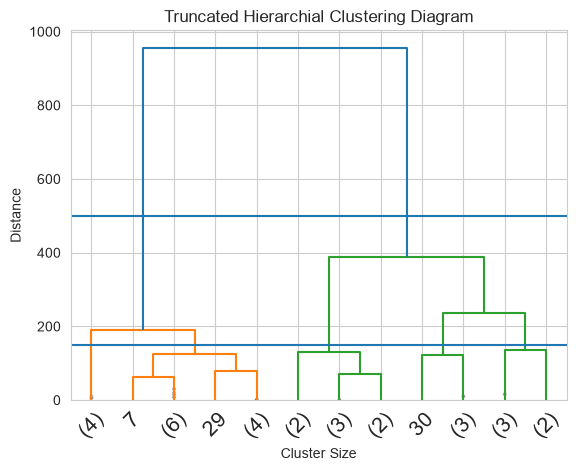

In [18]:
dendrogram(Z,truncate_mode='lastp', p=12, leaf_rotation=45.,leaf_font_size=15,show_contracted=True)
plt.title('Truncated Hierarchial Clustering Diagram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')

plt.axhline(y=500)
plt.axhline(y=150)
plt.show()

### Generating hierarchical clusters

In [19]:
k=2
Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
Hclustering.fit(X)

sm.accuracy_score(y,Hclustering.labels_)

0.78125

In [ ]:
k=2
Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='average')
Hclustering.fit(X)

sm.accuracy_score(y,Hclustering.labels_)

0.71875

In [ ]:
k=2
Hclustering = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='average')
Hclustering.fit(X)

sm.accuracy_score(y,Hclustering.labels_)